# This notebook builds the **DINOv2-based image retrieval prototype with background removal** for Step 1.
---

This notebook is a separate experimental variant of `step_1-01_dinov2_image_retrieval.ipynb`.
It removes image backgrounds locally before creating DINOv2 embeddings and writes separate `_bg_removed` cache/output files.

## Expected folder structure

```text
step_1/
  notebooks/
    step_1-02_dinov2_image_retrieval_background_removal.ipynb
  data/
    true_mapping.xlsx
    dataset_dev/
      gallery/
        object_001/
          img_001.jpg
          img_002.jpg
        object_002/
          img_001.jpg
      query/
        img_001.jpg
        img_002.jpg
        ...
  outputs/
```

In [1]:
%pip install -q pandas openpyxl pillow numpy faiss-cpu torch torchvision transformers tqdm scikit-learn matplotlib rembg onnxruntime

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import json
import io
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import faiss
import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, AutoModel

# Starting thresholds copied from the raw-image baseline.
# Run section 13 to find thresholds tuned for background-removed embeddings.
BEST_SCORE_THRESHOLD = 0.50
BEST_MARGIN_THRESHOLD = 0.03

# Retrieval settings
TOP_K_IMAGES = 30
TOP_K_OBJECTS = 5
TOP_N_PER_OBJECT = 2

# Background-removal preprocessing settings
BACKGROUND_REMOVAL_MODEL = "u2net"
BACKGROUND_FILL_COLOR = (255, 255, 255)
PREPROCESSING_LABEL = "bg_removed"
CACHE_SUFFIX = "_bg_removed"

/Users/memerchik/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/memerchik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Configure paths

In [3]:
# Resolve the step root whether the notebook is launched from step_1/notebooks
# or from a copied working directory in another environment.
NOTEBOOK_DIR = Path.cwd().resolve()
STEP_ROOT_CANDIDATES = [NOTEBOOK_DIR.parent, NOTEBOOK_DIR / "step_1", NOTEBOOK_DIR]
STEP_ROOT = next((path for path in STEP_ROOT_CANDIDATES if (path / "data").exists()), NOTEBOOK_DIR.parent)

PROJECT_ROOT = STEP_ROOT / "data"
OUTPUTS_DIR = STEP_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDINGS_PATH = OUTPUTS_DIR / f"gallery_embeddings{CACHE_SUFFIX}.npy"
INDEX_PATH = OUTPUTS_DIR / f"gallery_faiss{CACHE_SUFFIX}.index"
METADATA_PATH = OUTPUTS_DIR / f"gallery_index_metadata{CACHE_SUFFIX}.csv"
METRICS_PATH = OUTPUTS_DIR / "metrics_bg_removed.json"
RESULTS_PATH = OUTPUTS_DIR / "query_results_bg_removed.csv"
THRESHOLD_SWEEP_PATH = OUTPUTS_DIR / "threshold_sweep_bg_removed.csv"
BEST_SWEEP_METRICS_PATH = OUTPUTS_DIR / "metrics_bg_removed_best_sweep.json"

print("Outputs folder:", OUTPUTS_DIR)

DATASET_DIR = PROJECT_ROOT / "dataset_dev"
GALLERY_DIR = DATASET_DIR / "gallery"
QUERY_DIR = DATASET_DIR / "query"
MAPPING_XLSX = PROJECT_ROOT / "true_mapping.xlsx"

MODEL_NAME = "facebook/dinov2-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

use_cache = (
    EMBEDDINGS_PATH.exists() and
    INDEX_PATH.exists() and
    METADATA_PATH.exists()
)

print("STEP_ROOT:", STEP_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("GALLERY_DIR exists:", GALLERY_DIR.exists(), GALLERY_DIR)
print("QUERY_DIR exists:", QUERY_DIR.exists(), QUERY_DIR)
print("MAPPING_XLSX exists:", MAPPING_XLSX.exists(), MAPPING_XLSX)
print("DEVICE:", DEVICE)
print("PREPROCESSING:", PREPROCESSING_LABEL)

Outputs folder: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/outputs
STEP_ROOT: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1
PROJECT_ROOT: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/data
GALLERY_DIR exists: True /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/data/dataset_dev/gallery
QUERY_DIR exists: True /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/data/dataset_dev/query
MAPPING_XLSX exists: True /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/data/true_mapping.xlsx
DEVICE: cpu
PREPROCESSING: bg_removed


## 2. Helper functions

In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image_file(path: Path) -> bool:
    return path.suffix.lower() in IMAGE_EXTS

def numeric_suffix(text: str):
    """
    Returns the last integer found in a string, or None.
    Examples:
      object_066 -> 66
      query_img_1 -> 1
      img_001 -> 1
    """
    matches = re.findall(r"(\d+)", str(text))
    return int(matches[-1]) if matches else None

def normalize_object_id(value):
    """
    Converts values like:
      7 -> object_007
      '66' -> object_066
      'object_7' -> object_007
      'none' -> None
    """
    if pd.isna(value):
        return None

    s = str(value).strip()
    if s.lower() == "none":
        return None

    n = numeric_suffix(s)
    if n is None:
        return None

    return f"object_{n:03d}"

def ensure_gallery_paths(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure cached gallery metadata has a non-sensitive relative path for storage
    and a usable absolute image_path column reconstructed in memory.
    """
    df = df.copy()

    if "image_relpath" not in df.columns:
        if "image_path" in df.columns:
            gallery_root = GALLERY_DIR.resolve()
            df["image_relpath"] = df["image_path"].apply(
                lambda p: str(Path(p).resolve().relative_to(gallery_root)) if pd.notna(p) else None
            )
        elif {"object_id", "image_name"}.issubset(df.columns):
            df["image_relpath"] = df.apply(
                lambda row: str(Path(str(row["object_id"])) / str(row["image_name"])),
                axis=1,
            )
        else:
            raise ValueError("Gallery metadata must contain either image_relpath or image_path")

    df["image_path"] = df["image_relpath"].apply(
        lambda p: str((GALLERY_DIR / Path(p)).resolve()) if pd.notna(p) else None
    )
    return df

def l2_normalize(vectors: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    return vectors / norms

def cosine_from_l2_distance(l2_dist: float) -> float:
    """
    If vectors are L2-normalized, squared L2 distance and cosine similarity relate as:
      ||x-y||^2 = 2 - 2*cos(x,y)
      cos(x,y) = 1 - d^2/2
    """
    return 1.0 - (l2_dist / 2.0)

background_removal_session = None


def require_background_removal_package():
    try:
        from rembg import remove, new_session
    except ImportError as exc:
        raise ImportError(
            "Background removal needs the optional packages `rembg` and `onnxruntime`. "
            "Run `%pip install -q rembg onnxruntime`, then rerun this notebook."
        ) from exc
    return remove, new_session


def get_background_removal_session():
    global background_removal_session
    if background_removal_session is None:
        _, new_session = require_background_removal_package()
        background_removal_session = new_session(BACKGROUND_REMOVAL_MODEL)
    return background_removal_session


def remove_image_background(image: Image.Image) -> Image.Image:
    remove, _ = require_background_removal_package()
    foreground = remove(
        image.convert("RGBA"),
        session=get_background_removal_session(),
    )

    if isinstance(foreground, Image.Image):
        foreground = foreground.convert("RGBA")
    elif isinstance(foreground, bytes):
        foreground = Image.open(io.BytesIO(foreground)).convert("RGBA")
    else:
        foreground = Image.fromarray(foreground).convert("RGBA")

    canvas = Image.new("RGBA", foreground.size, BACKGROUND_FILL_COLOR + (255,))
    canvas.alpha_composite(foreground)
    return canvas.convert("RGB")


def preprocess_image_for_embedding(image: Image.Image) -> Image.Image:
    return remove_image_background(image.convert("RGB"))


def load_image_for_embedding(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return preprocess_image_for_embedding(img)

def show_image(path, title=None, figsize=(4, 4), preprocess=False):
    with Image.open(path) as img:
        img = preprocess_image_for_embedding(img) if preprocess else img.convert("RGB")
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 3. Load gallery and query images

In [5]:
query_records = []
for img_path in sorted(QUERY_DIR.rglob("*")):
    if img_path.is_file() and is_image_file(img_path):
        query_records.append({
            "query_path": str(img_path),
            "query_name": img_path.name,
            "query_stem": img_path.stem,
            "query_num": numeric_suffix(img_path.stem),
        })

query_df = pd.DataFrame(query_records)

if not use_cache:
    if not GALLERY_DIR.exists():
        raise FileNotFoundError(
            f"No {PREPROCESSING_LABEL} gallery cache exists and the gallery folder is missing: {GALLERY_DIR}. "
            "Provide the gallery folder to rebuild the background-removed cache, or use the raw-image notebook."
        )

    gallery_records = []
    gallery_object_dirs = sorted([p for p in GALLERY_DIR.iterdir() if p.is_dir()])

    for object_dir in gallery_object_dirs:
        object_id = object_dir.name
        for img_path in sorted(object_dir.rglob("*")):
            if img_path.is_file() and is_image_file(img_path):
                gallery_records.append({
                    "object_id": object_id,
                    "image_relpath": str(img_path.relative_to(GALLERY_DIR)),
                    "image_name": img_path.name,
                })

    gallery_df = ensure_gallery_paths(pd.DataFrame(gallery_records))
else:
    print("Loading cached gallery metadata...")
    gallery_df = ensure_gallery_paths(pd.read_csv(METADATA_PATH))

print(f"Gallery objects: {gallery_df['object_id'].nunique() if not gallery_df.empty else 0}")
print(f"Gallery images:  {len(gallery_df)}")
print(f"Query images:    {len(query_df)}")

display(gallery_df.drop(columns=["image_path"], errors="ignore").head())
display(query_df.drop(columns=["query_path"], errors="ignore").head())

Loading cached gallery metadata...
Gallery objects: 74
Gallery images:  1088
Query images:    89


,object_id,image_relpath,image_name,preprocessing
0,object_001,object_001/img_001.jpg,img_001.jpg,bg_removed
1,object_001,object_001/img_002.jpg,img_002.jpg,bg_removed
2,object_001,object_001/img_003.jpg,img_003.jpg,bg_removed
3,object_001,object_001/img_004.jpg,img_004.jpg,bg_removed
4,object_001,object_001/img_005.jpg,img_005.jpg,bg_removed


,query_name,query_stem,query_num
0,img_001.JPG,img_001,1
1,img_002.JPG,img_002,2
2,img_003.JPG,img_003,3
3,img_004.JPG,img_004,4
4,img_005.JPG,img_005,5


## 4. Load and normalize `true_mapping.xlsx`

This code tries to infer the two important columns:
- query identifier
- target object identifier or `none`

In [6]:
mapping_raw = pd.read_excel(MAPPING_XLSX, header=None).dropna(how="all")
display(mapping_raw.head())

if mapping_raw.shape[1] < 2:
    raise ValueError("Expected at least 2 columns in true_mapping.xlsx")

# Take the first two columns by default
mapping = mapping_raw.iloc[:, :2].copy()
mapping.columns = ["mapping_query_key", "mapping_target_raw"]

mapping["mapping_query_key"] = mapping["mapping_query_key"].astype(str).str.strip()
mapping["target_object_id"] = mapping["mapping_target_raw"].apply(normalize_object_id)
mapping["mapping_query_num"] = mapping["mapping_query_key"].apply(numeric_suffix)

display(mapping.head(10))
print("Known targets:", mapping["target_object_id"].notna().sum())
print("Unknown/none targets:", mapping["target_object_id"].isna().sum())

,0,1
0,query_img_1,66
1,query_img_2,60
2,query_img_3,none
3,query_img_4,7
4,query_img_5,none


,mapping_query_key,mapping_target_raw,target_object_id,mapping_query_num
0,query_img_1,66,object_066,1
1,query_img_2,60,object_060,2
2,query_img_3,none,None,3
3,query_img_4,7,object_007,4
4,query_img_5,none,None,5
5,query_img_6,34,object_034,6
6,query_img_7,33,object_033,7
7,query_img_8,18,object_018,8
8,query_img_9,17,object_017,9
9,query_img_10,62,object_062,10


Known targets: 71
Unknown/none targets: 29


## 5. Match mapping rows to actual query image files

This resolver tries the following in this order:

1. exact filename match
2. exact stem match
3. numeric suffix match (for cases like `query_img_1` <-> `img_001.jpg`)

In [7]:
query_name_to_path = dict(zip(query_df["query_name"], query_df["query_path"]))
query_stem_to_path = dict(zip(query_df["query_stem"], query_df["query_path"]))

# numeric suffix -> list of query paths
query_num_to_paths = defaultdict(list)
for _, row in query_df.iterrows():
    if row["query_num"] is not None:
        query_num_to_paths[int(row["query_num"])].append(row["query_path"])

resolved_query_paths = []
resolution_method = []

for _, row in mapping.iterrows():
    key = row["mapping_query_key"]
    key_num = row["mapping_query_num"]

    path = None
    method = None

    # 1) exact filename match
    if key in query_name_to_path:
        path = query_name_to_path[key]
        method = "exact_filename"

    # 2) exact stem match
    elif key in query_stem_to_path:
        path = query_stem_to_path[key]
        method = "exact_stem"

    # 3) numeric suffix match
    elif key_num is not None and len(query_num_to_paths.get(int(key_num), [])) == 1:
        path = query_num_to_paths[int(key_num)][0]
        method = "numeric_suffix"

    resolved_query_paths.append(path)
    resolution_method.append(method)

mapping["query_path"] = resolved_query_paths
mapping["resolution_method"] = resolution_method

display(mapping.drop(columns=["query_path"], errors="ignore").head(20))

unresolved = mapping[mapping["query_path"].isna()].copy()
print("Resolved rows:", len(mapping) - len(unresolved))
print("Unresolved rows:", len(unresolved))

if len(unresolved):
    display(unresolved.drop(columns=["query_path"], errors="ignore").head(20))
    print("Some mapping rows could not be matched to query files.")
    print("If needed, manually create a mapping between Excel keys and query filenames.")

,mapping_query_key,mapping_target_raw,target_object_id,mapping_query_num,resolution_method
0,query_img_1,66,object_066,1,numeric_suffix
1,query_img_2,60,object_060,2,numeric_suffix
2,query_img_3,none,None,3,numeric_suffix
3,query_img_4,7,object_007,4,numeric_suffix
4,query_img_5,none,None,5,numeric_suffix
5,query_img_6,34,object_034,6,numeric_suffix
6,query_img_7,33,object_033,7,numeric_suffix
7,query_img_8,18,object_018,8,numeric_suffix
8,query_img_9,17,object_017,9,numeric_suffix
9,query_img_10,62,object_062,10,numeric_suffix


Resolved rows: 87
Unresolved rows: 13


,mapping_query_key,mapping_target_raw,target_object_id,mapping_query_num,resolution_method
71,query_img_72,36,object_036,72,None
88,query_img_89,NaN,None,89,None
89,query_img_90,NaN,None,90,None
90,query_img_91,NaN,None,91,None
91,query_img_92,NaN,None,92,None
92,query_img_93,NaN,None,93,None
93,query_img_94,NaN,None,94,None
94,query_img_95,NaN,None,95,None
95,query_img_96,NaN,None,96,None
96,query_img_97,NaN,None,97,None


Some mapping rows could not be matched to query files.
If needed, manually create a mapping between Excel keys and query filenames.


## 6. Build the evaluation table

In [8]:
eval_df = mapping.dropna(subset=["query_path"]).copy()
eval_df["query_name"] = eval_df["query_path"].apply(lambda p: Path(p).name)
eval_df["is_known"] = eval_df["target_object_id"].notna()

print("Evaluation rows:", len(eval_df))
print("Known queries:", int(eval_df["is_known"].sum()))
print("Unknown queries:", int((~eval_df["is_known"]).sum()))

display(eval_df.drop(columns=["query_path"], errors="ignore").head(10))

Evaluation rows: 87
Known queries: 70
Unknown queries: 17


,mapping_query_key,mapping_target_raw,target_object_id,mapping_query_num,resolution_method,query_name,is_known
0,query_img_1,66,object_066,1,numeric_suffix,img_001.JPG,True
1,query_img_2,60,object_060,2,numeric_suffix,img_002.JPG,True
2,query_img_3,none,None,3,numeric_suffix,img_003.JPG,False
3,query_img_4,7,object_007,4,numeric_suffix,img_004.JPG,True
4,query_img_5,none,None,5,numeric_suffix,img_005.JPG,False
5,query_img_6,34,object_034,6,numeric_suffix,img_006.JPG,True
6,query_img_7,33,object_033,7,numeric_suffix,img_007.JPG,True
7,query_img_8,18,object_018,8,numeric_suffix,img_008.JPG,True
8,query_img_9,17,object_017,9,numeric_suffix,img_009.JPG,True
9,query_img_10,62,object_062,10,numeric_suffix,img_010.JPG,True


## 7. Load DINOv2

Using the pretrained DINOv2 model as a **feature extractor**.

In [9]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

print("Loaded model:", MODEL_NAME)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded model: facebook/dinov2-base


## 8. Embedding functions

This variant removes the visible image background locally with `rembg`, places the foreground object on a white background, and then computes DINOv2 embeddings. The same preprocessing is applied to both gallery and query images.

In [10]:
from torch.utils.data import Dataset, DataLoader

class ImagePathDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = list(image_paths)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = load_image_for_embedding(path)
        return img, path

def collate_images_and_paths(batch):
    images = [item[0] for item in batch]
    paths = [item[1] for item in batch]
    return images, paths

@torch.inference_mode()
def embed_image_paths_parallel(image_paths, batch_size=32, num_workers=4, desc="Embedding images"):
    if num_workers > 0:
        # rembg sessions are simpler and more reliable in the main process.
        num_workers = 0

    dataset = ImagePathDataset(image_paths)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_images_and_paths,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
    )

    all_embeds = []

    for images, batch_paths in tqdm(loader, desc=desc):
        inputs = processor(images=images, return_tensors="pt")
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        outputs = model(**inputs)

        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            batch_embeds = outputs.pooler_output
        else:
            batch_embeds = outputs.last_hidden_state.mean(dim=1)

        batch_embeds = batch_embeds.detach().to("cpu").float().numpy()
        all_embeds.append(batch_embeds)

    all_embeds = np.concatenate(all_embeds, axis=0).astype("float32")
    all_embeds = l2_normalize(all_embeds)
    return all_embeds

## 9. Embed gallery images and build a FAISS index

In [11]:
# Cache-aware gallery embedding + FAISS index builder/loader

use_cache = (
    EMBEDDINGS_PATH.exists() and
    INDEX_PATH.exists() and
    METADATA_PATH.exists()
)

if use_cache:
    print(f"Loading cached gallery embeddings and FAISS index for preprocessing={PREPROCESSING_LABEL}...")
    gallery_embeddings = np.load(EMBEDDINGS_PATH).astype("float32")
    gallery_df = ensure_gallery_paths(pd.read_csv(METADATA_PATH))
    index = faiss.read_index(str(INDEX_PATH))

    print("Loaded cache.")
    print("gallery_embeddings shape:", gallery_embeddings.shape)
    print("FAISS index ntotal:", index.ntotal)

else:
    gallery_paths = gallery_df["image_path"].tolist()
    print(f"No {PREPROCESSING_LABEL} cache found. Building gallery embeddings and FAISS index...")

    gallery_embeddings = embed_image_paths_parallel(
        gallery_paths,
        batch_size=32 if DEVICE == "mps" else 16,
        num_workers=4 if DEVICE == "cuda" else 0,
        desc="Embedding gallery",
    )

    embedding_dim = gallery_embeddings.shape[1]
    index = faiss.IndexFlatL2(embedding_dim)
    index.add(gallery_embeddings)

    gallery_metadata = gallery_df.drop(columns=["image_path"], errors="ignore").copy()
    gallery_metadata["preprocessing"] = PREPROCESSING_LABEL

    np.save(EMBEDDINGS_PATH, gallery_embeddings)
    gallery_metadata.to_csv(METADATA_PATH, index=False)
    faiss.write_index(index, str(INDEX_PATH))

    print("Built and saved cache.")
    print("gallery_embeddings shape:", gallery_embeddings.shape)
    print("FAISS index ntotal:", index.ntotal)

Loading cached gallery embeddings and FAISS index for preprocessing=bg_removed...
Loaded cache.
gallery_embeddings shape: (1088, 768)
FAISS index ntotal: 1088


## 10. Retrieval helpers

Retrieving at the **image level**, then aggregating to the **object level**.

Baseline aggregation rule:
- per object, keep the **best** similarity score among its matched images

In [12]:
from collections import defaultdict
import numpy as np

def retrieve_objects_for_query(query_path, top_k_images=30, top_k_objects=5, top_n_per_object=2):
    query_embed = embed_image_paths_parallel([query_path], batch_size=1, num_workers=0, desc="Embedding query")
    distances, indices = index.search(query_embed, top_k_images)

    distances = distances[0]
    indices = indices[0]

    image_matches = []
    object_scores = defaultdict(list)

    for dist, idx in zip(distances, indices):
        if idx < 0:
            continue

        rec = gallery_df.iloc[int(idx)]
        object_id = rec["object_id"]
        score = cosine_from_l2_distance(float(dist))

        image_matches.append({
            "object_id": object_id,
            "gallery_path": rec["image_path"],
            "gallery_name": rec["image_name"],
            "score": score,
        })

        object_scores[object_id].append(score)

    ranked_objects = []
    for object_id, scores in object_scores.items():
        scores = sorted(scores, reverse=True)
        agg_score = float(np.mean(scores[:top_n_per_object]))

        ranked_objects.append({
            "object_id": object_id,
            "score": agg_score,
            "num_matches": len(scores),
            "best_score": scores[0],
        })

    ranked_objects = sorted(
        ranked_objects,
        key=lambda x: x["score"],
        reverse=True
    )[:top_k_objects]

    return ranked_objects, image_matches

def predict_object_or_none(
    query_path,
    score_threshold=0.66,
    margin_threshold=0.03,
    top_k_images=30,
    top_k_objects=5,
    top_n_per_object=2,
):
    ranked_objects, image_matches = retrieve_objects_for_query(
        query_path=query_path,
        top_k_images=top_k_images,
        top_k_objects=top_k_objects,
        top_n_per_object=top_n_per_object,
    )

    if not ranked_objects:
        return None, ranked_objects, image_matches

    best_object = ranked_objects[0]["object_id"]
    best_score = ranked_objects[0]["score"]
    second_score = ranked_objects[1]["score"] if len(ranked_objects) > 1 else -1.0
    margin = best_score - second_score

    if best_score < score_threshold:
        return None, ranked_objects, image_matches

    if margin < margin_threshold:
        return None, ranked_objects, image_matches

    return best_object, ranked_objects, image_matches

## 11. Try one query manually

In [13]:
sample_query_path = eval_df.iloc[0]["query_path"]
sample_true = eval_df.iloc[0]["target_object_id"]

#print("Sample query:", sample_query_path)
print("True target:", sample_true)

pred, ranked_objects, image_matches = predict_object_or_none(sample_query_path)

print("Predicted:", pred)
print("Top objects:")
for r in ranked_objects[:5]:
    print(r)

# show_image(sample_query_path, title=f"Query: {Path(sample_query_path).name}")
# for match in image_matches[:3]:
#     show_image(match["gallery_path"], title=f"{match['object_id']} | score={match['score']:.3f}")

True target: object_066


Embedding query: 100%|██████████| 1/1 [00:39<00:00, 39.25s/it]

Predicted: object_072
Top objects:
{'object_id': 'object_072', 'score': 0.7127765119075775, 'num_matches': 17, 'best_score': 0.7312674522399902}
{'object_id': 'object_071', 'score': 0.584490567445755, 'num_matches': 3, 'best_score': 0.6236086487770081}
{'object_id': 'object_068', 'score': 0.5514622777700424, 'num_matches': 4, 'best_score': 0.5612337589263916}
{'object_id': 'object_069', 'score': 0.5247166305780411, 'num_matches': 3, 'best_score': 0.5276574194431305}
{'object_id': 'object_067', 'score': 0.49083957076072693, 'num_matches': 3, 'best_score': 0.4971961975097656}


## 12. Evaluate across all queries for one threshold

In [14]:
def evaluate_thresholds(
    eval_df,
    score_threshold=0.66,
    margin_threshold=0.03,
    top_k_images=30,
    top_k_objects=5,
    top_n_per_object=2,
):
    rows = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df),
                       desc=f"Evaluating score={score_threshold:.2f}, margin={margin_threshold:.2f}"):
        query_path = row["query_path"]
        true_object = row["target_object_id"]
        is_known = row["is_known"]

        pred_object, ranked_objects, _ = predict_object_or_none(
            query_path=query_path,
            score_threshold=score_threshold,
            margin_threshold=margin_threshold,
            top_k_images=top_k_images,
            top_k_objects=top_k_objects,
            top_n_per_object=top_n_per_object,
        )

        ranked_ids = [r["object_id"] for r in ranked_objects]
        best_score = ranked_objects[0]["score"] if ranked_objects else None
        second_score = ranked_objects[1]["score"] if len(ranked_objects) > 1 else None
        margin = (best_score - second_score) if (best_score is not None and second_score is not None) else None

        top1_correct_known = bool(is_known and len(ranked_ids) >= 1 and ranked_ids[0] == true_object)
        top3_correct_known = bool(is_known and true_object in ranked_ids[:3])
        unknown_correct = bool((not is_known) and pred_object is None)
        overall_correct = bool((is_known and pred_object == true_object) or ((not is_known) and pred_object is None))

        rows.append({
            "query_path": query_path,
            "query_name": Path(query_path).name,
            "true_object": true_object,
            "is_known": is_known,
            "pred_object": pred_object,
            "best_score": best_score,
            "second_score": second_score,
            "margin": margin,
            "ranked_ids": ranked_ids,
            "top1_correct_known": top1_correct_known,
            "top3_correct_known": top3_correct_known,
            "unknown_correct": unknown_correct,
            "overall_correct": overall_correct,
        })

    results_df = pd.DataFrame(rows)

    known_mask = results_df["is_known"]
    unknown_mask = ~results_df["is_known"]

    metrics = {
        "preprocessing": PREPROCESSING_LABEL,
        "background_removal_enabled": True,
        "score_threshold": score_threshold,
        "margin_threshold": margin_threshold,
        "n_total": int(len(results_df)),
        "n_known": int(known_mask.sum()),
        "n_unknown": int(unknown_mask.sum()),
        "top1_known": float(results_df.loc[known_mask, "top1_correct_known"].mean()) if known_mask.any() else np.nan,
        "top3_known": float(results_df.loc[known_mask, "top3_correct_known"].mean()) if known_mask.any() else np.nan,
        "unknown_rejection": float(results_df.loc[unknown_mask, "unknown_correct"].mean()) if unknown_mask.any() else np.nan,
        "overall_accuracy": float(results_df["overall_correct"].mean()) if len(results_df) else np.nan,
    }

    return metrics, results_df

# metrics, results_df = evaluate_thresholds(
#     eval_df,
#     score_threshold=0.66,
#     margin_threshold=0.03,
#     top_k_images=30,
#     top_k_objects=5,
#     top_n_per_object=2,
# )

# metrics

## 13. Search for better thresholds for background-removed embeddings

The starting thresholds near the top of this notebook were copied from the raw-image baseline. Background removal changes the embedding space, so the score and margin thresholds should be tuned again for this variant.

This section first computes the background-removed query rankings once, then sweeps many score/margin combinations from those cached rankings. That avoids re-running background removal for every threshold pair.

In [15]:
def evaluate_thresholds_from_rankings(results_df, score_threshold, margin_threshold):
    rows = []

    for _, row in results_df.iterrows():
        ranked_ids = list(row["ranked_ids"])
        true_object = row["true_object"]
        is_known = bool(row["is_known"])
        best_score = row["best_score"]
        second_score = row["second_score"]
        margin = row["margin"]

        approved = (
            len(ranked_ids) > 0 and
            pd.notna(best_score) and
            float(best_score) >= score_threshold and
            (pd.isna(margin) or float(margin) >= margin_threshold)
        )
        pred_object = ranked_ids[0] if approved else None

        rows.append({
            "query_path": row["query_path"],
            "query_name": row["query_name"],
            "true_object": true_object,
            "is_known": is_known,
            "pred_object": pred_object,
            "best_score": best_score,
            "second_score": second_score,
            "margin": margin,
            "ranked_ids": ranked_ids,
            "top1_correct_known": bool(is_known and len(ranked_ids) >= 1 and ranked_ids[0] == true_object),
            "top3_correct_known": bool(is_known and true_object in ranked_ids[:3]),
            "top5_correct_known": bool(is_known and true_object in ranked_ids[:5]),
            "unknown_correct": bool((not is_known) and pred_object is None),
            "overall_correct": bool((is_known and pred_object == true_object) or ((not is_known) and pred_object is None)),
        })

    threshold_results_df = pd.DataFrame(rows)
    known_mask = threshold_results_df["is_known"]
    unknown_mask = ~threshold_results_df["is_known"]
    approved_mask = threshold_results_df["pred_object"].notna()

    metrics = {
        "preprocessing": PREPROCESSING_LABEL,
        "background_removal_enabled": True,
        "score_threshold": float(score_threshold),
        "margin_threshold": float(margin_threshold),
        "n_total": int(len(threshold_results_df)),
        "n_known": int(known_mask.sum()),
        "n_unknown": int(unknown_mask.sum()),
        "top1_known": float(threshold_results_df.loc[known_mask, "top1_correct_known"].mean()) if known_mask.any() else np.nan,
        "top3_known": float(threshold_results_df.loc[known_mask, "top3_correct_known"].mean()) if known_mask.any() else np.nan,
        "top5_known": float(threshold_results_df.loc[known_mask, "top5_correct_known"].mean()) if known_mask.any() else np.nan,
        "unknown_rejection": float(threshold_results_df.loc[unknown_mask, "unknown_correct"].mean()) if unknown_mask.any() else np.nan,
        "overall_accuracy": float(threshold_results_df["overall_correct"].mean()) if len(threshold_results_df) else np.nan,
        "approval_rate": float(approved_mask.mean()) if len(threshold_results_df) else np.nan,
    }

    return metrics, threshold_results_df


# Compute bg-removed query rankings once. The threshold sweep below reuses these rows.
_, threshold_base_results_df = evaluate_thresholds(
    eval_df,
    score_threshold=-1.0,
    margin_threshold=-1.0,
    top_k_images=TOP_K_IMAGES,
    top_k_objects=TOP_K_OBJECTS,
    top_n_per_object=TOP_N_PER_OBJECT,
)

score_thresholds = np.arange(0.30, 0.91, 0.01)
margin_thresholds = np.arange(0.00, 0.201, 0.005)

all_metrics = []

for score_thr in score_thresholds:
    for margin_thr in margin_thresholds:
        metrics, _ = evaluate_thresholds_from_rankings(
            threshold_base_results_df,
            score_threshold=float(score_thr),
            margin_threshold=float(margin_thr),
        )
        all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics)
display(metrics_df.sort_values(["overall_accuracy", "top1_known", "unknown_rejection"], ascending=False).head(20))

best_row = metrics_df.sort_values(
    ["overall_accuracy", "top1_known", "unknown_rejection"],
    ascending=False,
).iloc[0]

best_score_threshold = float(best_row["score_threshold"])
best_margin_threshold = float(best_row["margin_threshold"])

print("Best score threshold:", best_score_threshold)
print("Best margin threshold:", best_margin_threshold)

best_row

Evaluating score=-1.00, margin=-1.00: 100%|██████████| 87/87 [00:37<00:00,  2.31it/s]


,preprocessing,background_removal_enabled,score_threshold,margin_threshold,n_total,n_known,n_unknown,top1_known,top3_known,top5_known,unknown_rejection,overall_accuracy,approval_rate
987,bg_removed,True,0.54,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.482759,0.586207
1028,bg_removed,True,0.55,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.482759,0.586207
1069,bg_removed,True,0.56,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.482759,0.586207
1110,bg_removed,True,0.57,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.482759,0.586207
1151,bg_removed,True,0.58,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.482759,0.586207
1192,bg_removed,True,0.59,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.482759,0.586207
1233,bg_removed,True,0.60,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.482759,0.586207
985,bg_removed,True,0.54,0.005,87,70,17,0.5,0.685714,0.757143,0.411765,0.482759,0.804598
1026,bg_removed,True,0.55,0.005,87,70,17,0.5,0.685714,0.757143,0.411765,0.482759,0.804598
1274,bg_removed,True,0.61,0.015,87,70,17,0.5,0.685714,0.757143,0.647059,0.471264,0.574713


Best score threshold: 0.5400000000000003
Best margin threshold: 0.015


preprocessing                 bg_removed
background_removal_enabled          True
score_threshold                     0.54
margin_threshold                   0.015
n_total                               87
n_known                               70
n_unknown                             17
top1_known                           0.5
top3_known                      0.685714
top5_known                      0.757143
unknown_rejection               0.647059
overall_accuracy                0.482759
approval_rate                   0.586207
Name: 987, dtype: object

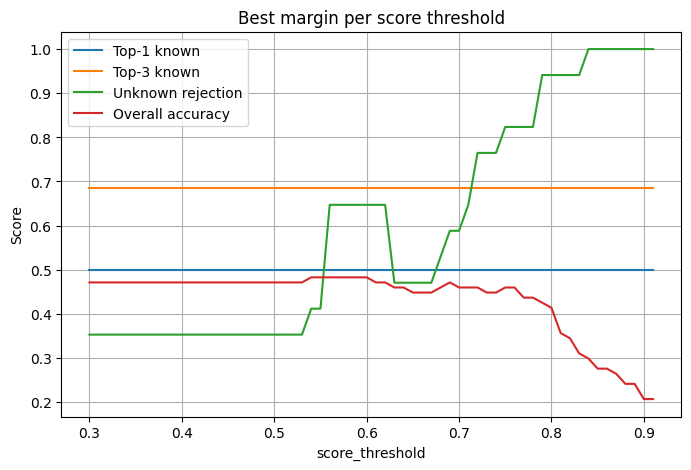

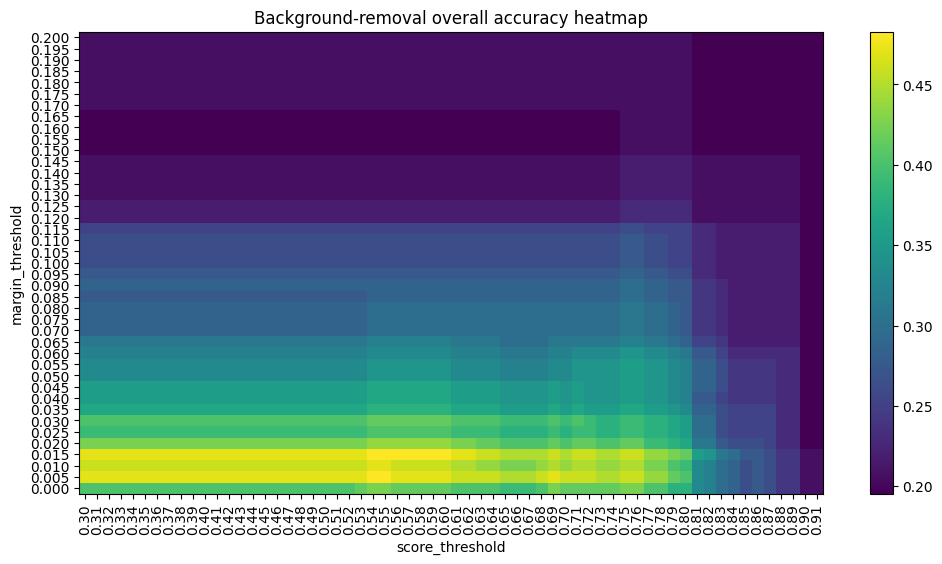

In [16]:
best_by_score = (
    metrics_df.sort_values(["score_threshold", "overall_accuracy"], ascending=[True, False])
    .groupby("score_threshold", as_index=False)
    .head(1)
    .sort_values("score_threshold")
)

plt.figure(figsize=(8, 5))
plt.plot(best_by_score["score_threshold"], best_by_score["top1_known"], label="Top-1 known")
plt.plot(best_by_score["score_threshold"], best_by_score["top3_known"], label="Top-3 known")
plt.plot(best_by_score["score_threshold"], best_by_score["unknown_rejection"], label="Unknown rejection")
plt.plot(best_by_score["score_threshold"], best_by_score["overall_accuracy"], label="Overall accuracy")
plt.xlabel("score_threshold")
plt.ylabel("Score")
plt.title("Best margin per score threshold")
plt.legend()
plt.grid(True)
plt.show()

pivot = metrics_df.pivot(
    index="margin_threshold",
    columns="score_threshold",
    values="overall_accuracy"
)

plt.figure(figsize=(12, 6))
plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns], rotation=90)
plt.yticks(range(len(pivot.index)), [f"{y:.3f}" for y in pivot.index])
plt.xlabel("score_threshold")
plt.ylabel("margin_threshold")
plt.title("Background-removal overall accuracy heatmap")
plt.colorbar()
plt.show()

## 14. Run final evaluation with the selected thresholds

If Section 13 was run, this uses `best_score_threshold` and `best_margin_threshold`. Otherwise, it falls back to the starting threshold constants near the top of the notebook.

In [17]:
selected_score_threshold = globals().get("best_score_threshold", BEST_SCORE_THRESHOLD)
selected_margin_threshold = globals().get("best_margin_threshold", BEST_MARGIN_THRESHOLD)

print("Selected score threshold:", selected_score_threshold)
print("Selected margin threshold:", selected_margin_threshold)

final_metrics, final_results_df = evaluate_thresholds(
    eval_df,
    score_threshold=selected_score_threshold,
    margin_threshold=selected_margin_threshold,
    top_k_images=TOP_K_IMAGES,
    top_k_objects=TOP_K_OBJECTS,
    top_n_per_object=TOP_N_PER_OBJECT,
)

print(json.dumps(final_metrics, indent=2))
display(final_results_df.drop(columns=["query_path"], errors="ignore").head(20))

Selected score threshold: 0.5400000000000003
Selected margin threshold: 0.015


Evaluating score=0.54, margin=0.01: 100%|██████████| 87/87 [00:38<00:00,  2.29it/s]

{
  "preprocessing": "bg_removed",
  "background_removal_enabled": true,
  "score_threshold": 0.5400000000000003,
  "margin_threshold": 0.015,
  "n_total": 87,
  "n_known": 70,
  "n_unknown": 17,
  "top1_known": 0.5,
  "top3_known": 0.6857142857142857,
  "unknown_rejection": 0.6470588235294118,
  "overall_accuracy": 0.4827586206896552
}


,query_name,true_object,is_known,pred_object,best_score,second_score,margin,ranked_ids,top1_correct_known,top3_correct_known,unknown_correct,overall_correct
0,img_001.JPG,object_066,True,object_072,0.712777,0.584491,0.128286,"[object_072, object_071, object_068, object_06...",False,False,False,False
1,img_002.JPG,object_060,True,object_060,0.783560,0.670573,0.112988,"[object_060, object_001, object_002, object_07...",True,True,False,True
2,img_003.JPG,None,False,object_001,0.713066,0.691250,0.021816,"[object_001, object_002, object_060, object_00...",False,False,False,False
3,img_004.JPG,object_007,True,object_001,0.723372,0.683097,0.040275,"[object_001, object_002, object_060, object_00...",False,False,False,False
4,img_005.JPG,None,False,None,0.804931,0.803619,0.001313,"[object_001, object_002, object_060, object_00...",False,False,True,True
5,img_006.JPG,object_034,True,None,0.555431,0.540560,0.014871,"[object_034, object_003, object_033, object_00...",True,True,False,False
6,img_007.JPG,object_033,True,None,0.523684,0.521808,0.001876,"[object_069, object_032, object_033, object_06...",False,True,False,False
7,img_008.JPG,object_018,True,object_014,0.825479,0.730126,0.095353,"[object_014, object_021, object_015, object_02...",False,False,False,False
8,img_009.JPG,object_017,True,object_055,0.784158,0.767638,0.016519,"[object_055, object_001, object_002, object_01...",False,False,False,False
9,img_010.JPG,object_062,True,None,0.855089,0.851844,0.003245,"[object_060, object_042, object_002, object_05...",False,False,False,False


## 15. Inspect errors

In [18]:
known_errors = final_results_df[
    (final_results_df["is_known"]) &
    (~final_results_df["top1_correct_known"])
].copy()

unknown_errors = final_results_df[
    (~final_results_df["is_known"]) &
    (~final_results_df["unknown_correct"])
].copy()

print("Known-query Top-1 errors:", len(known_errors))
print("Unknown-query rejection errors:", len(unknown_errors))

display(known_errors.drop(columns=["query_path"], errors="ignore").head(10))
display(unknown_errors.drop(columns=["query_path"], errors="ignore").head(10))

Known-query Top-1 errors: 35
Unknown-query rejection errors: 6


,query_name,true_object,is_known,pred_object,best_score,second_score,margin,ranked_ids,top1_correct_known,top3_correct_known,unknown_correct,overall_correct
0,img_001.JPG,object_066,True,object_072,0.712777,0.584491,0.128286,"[object_072, object_071, object_068, object_06...",False,False,False,False
3,img_004.JPG,object_007,True,object_001,0.723372,0.683097,0.040275,"[object_001, object_002, object_060, object_00...",False,False,False,False
6,img_007.JPG,object_033,True,None,0.523684,0.521808,0.001876,"[object_069, object_032, object_033, object_06...",False,True,False,False
7,img_008.JPG,object_018,True,object_014,0.825479,0.730126,0.095353,"[object_014, object_021, object_015, object_02...",False,False,False,False
8,img_009.JPG,object_017,True,object_055,0.784158,0.767638,0.016519,"[object_055, object_001, object_002, object_01...",False,False,False,False
9,img_010.JPG,object_062,True,None,0.855089,0.851844,0.003245,"[object_060, object_042, object_002, object_05...",False,False,False,False
10,img_011.JPG,object_018,True,None,0.809983,0.807437,0.002546,"[object_060, object_018, object_005, object_00...",False,True,False,False
11,img_012.JPG,object_044,True,None,0.737741,0.723816,0.013925,"[object_048, object_062, object_055, object_05...",False,False,False,False
13,img_014.JPG,object_046,True,object_019,0.763434,0.748329,0.015105,"[object_019, object_045, object_054, object_00...",False,False,False,False
14,img_015.JPG,object_049,True,None,0.720097,0.719358,0.000739,"[object_055, object_001, object_054, object_01...",False,False,False,False


,query_name,true_object,is_known,pred_object,best_score,second_score,margin,ranked_ids,top1_correct_known,top3_correct_known,unknown_correct,overall_correct
2,img_003.JPG,None,False,object_001,0.713066,0.691250,0.021816,"[object_001, object_002, object_060, object_00...",False,False,False,False
53,img_054.JPG,None,False,object_003,0.745426,0.580049,0.165377,"[object_003, object_002, object_073, object_06...",False,False,False,False
54,img_055.JPG,None,False,object_003,0.686123,0.620886,0.065236,"[object_003, object_002, object_060, object_01...",False,False,False,False
64,img_065.JPG,None,False,object_038,0.715026,0.687636,0.027390,"[object_038, object_060, object_002, object_00...",False,False,False,False
65,img_066.JPG,None,False,object_005,0.830170,0.787272,0.042899,"[object_005, object_030, object_007, object_03...",False,False,False,False
86,img_088.JPG,None,False,object_068,0.709375,0.647332,0.062042,"[object_068, object_069, object_067, object_06...",False,False,False,False


In [19]:
def inspect_result_row(
    result_row,
    score_threshold=0.66,
    margin_threshold=0.03,
    top_k_images=30,
    top_k_objects=5,
    top_n_per_object=2,
    n_gallery=5,
):
    query_path = result_row["query_path"]
    true_object = result_row["true_object"]

    pred_object, ranked_objects, image_matches = predict_object_or_none(
        query_path=query_path,
        score_threshold=score_threshold,
        margin_threshold=margin_threshold,
        top_k_images=top_k_images,
        top_k_objects=top_k_objects,
        top_n_per_object=top_n_per_object,
    )

    print("Query:", query_path)
    print("True:", true_object)
    print("Pred:", pred_object)
    print("Top objects:")
    for r in ranked_objects:
        print(
            f"  {r['object_id']}: agg={r['score']:.4f}, "
            f"best={r['best_score']:.4f}, matches={r['num_matches']}"
        )

    show_image(query_path, title=f"Query | true={true_object} | pred={pred_object}")

    shown = 0
    seen_paths = set()
    missing_gallery_paths = 0
    for match in image_matches:
        if match["gallery_path"] in seen_paths:
            continue
        seen_paths.add(match["gallery_path"])
        if not Path(match["gallery_path"]).exists():
            missing_gallery_paths += 1
            continue
        show_image(match["gallery_path"], title=f"{match['object_id']} | score={match['score']:.4f}")
        shown += 1
        if shown >= n_gallery:
            break

    if shown == 0 and missing_gallery_paths > 0:
        print("Gallery image files are not available locally, so matched gallery previews were skipped.")

# Example:
# inspect_result_row(known_errors.iloc[0], score_threshold=best_score_threshold, margin_threshold=best_margin_threshold)

## 16. Save outputs

This saves:
- metrics
- per-query predictions
- threshold-sweep results, if Section 13 was run

In [20]:
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2)

final_results_df.drop(columns=["query_path"], errors="ignore").to_csv(RESULTS_PATH, index=False)

print("Saved:", METRICS_PATH)
print("Saved:", RESULTS_PATH)

if "metrics_df" in globals():
    metrics_df.to_csv(THRESHOLD_SWEEP_PATH, index=False)
    best_sweep_metrics = {
        key: (value.item() if hasattr(value, "item") else value)
        for key, value in best_row.to_dict().items()
    }
    with open(BEST_SWEEP_METRICS_PATH, "w", encoding="utf-8") as f:
        json.dump(best_sweep_metrics, f, indent=2)
    print("Saved:", THRESHOLD_SWEEP_PATH)
    print("Saved:", BEST_SWEEP_METRICS_PATH)
else:
    print("Threshold sweep was not saved because Section 13 was not run in this session.")

Saved: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/outputs/metrics_bg_removed.json
Saved: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/outputs/query_results_bg_removed.csv
Saved: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/outputs/threshold_sweep_bg_removed.csv
Saved: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/outputs/metrics_bg_removed_best_sweep.json


## Future improvements

The next improvements are:

1. background-removal experiments
   - retune score and margin thresholds for this preprocessing variant
   - compare raw-image, background-removed, and center-crop candidates

2. fine-tuning
   - use query <-> correct object mapping as supervised signal